# Exploratory Data Analysis - Household Power Consumption

This notebook performs EDA on the UCI Household Power Consumption dataset.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_config, load_raw_data, get_data_info
from src.data.cleaner import preprocess_pipeline, save_processed_data
from src.visualization.plots import setup_plot_style

setup_plot_style()
# %matplotlib inline

## 1. Load Data

In [2]:
# Load configuration
config = load_config('../configs/params.yaml')
config

{'seed': 42,
 'project_name': 'household_power_consumption',
 'data': {'raw_path': 'household_power_consumption.txt',
  'processed_path': 'data/processed/cleaned_data.csv'},
 'preprocessing': {'missing_value_symbol': '?',
  'separator': ';',
  'interpolation_method': 'linear',
  'timestamp_format': '%d/%m/%Y %H:%M:%S'},
 'association': {'min_support': 0.01,
  'min_confidence': 0.5,
  'min_lift': 1.0,
  'discretization_bins': 3},
 'clustering': {'n_clusters': 5, 'algorithm': 'kmeans', 'random_state': 42},
 'forecasting': {'test_size': 0.2, 'seasonal_period': 24},
 'anomaly': {'method': 'isolation_forest',
  'contamination': 0.05,
  'z_threshold': 3.0},
 'outputs': {'figures': 'outputs/figures/',
  'tables': 'outputs/tables/',
  'models': 'outputs/models/'}}

In [3]:
# Load raw data
df_raw = load_raw_data('../household_power_consumption.txt', config)
df_raw.head()

Loaded 2075259 records from ../household_power_consumption.txt
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Missing values:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
# Basic info
info = get_data_info(df_raw)
print(f"Number of records: {info['n_records']:,}")
print(f"Date range: {info['date_range'][0]} to {info['date_range'][1]}")

Number of records: 2,075,259
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


## 2. Data Cleaning & Preprocessing

In [5]:
# Apply preprocessing pipeline
df = preprocess_pipeline(df_raw, config)
df.head()

Starting preprocessing pipeline...
Missing values after cleaning: 0
Preprocessing complete!
Final shape: (2075259, 14)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,day_of_month,month,year,is_weekend,is_peak_hour
datetime,,,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,5,16,12,2006,1,0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,5,16,12,2006,1,0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,5,16,12,2006,1,0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,5,16,12,2006,1,0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,5,16,12,2006,1,0


In [6]:
# Check columns after preprocessing
print(f"Columns: {list(df.columns)}")
print(f"\nShape: {df.shape}")

Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'is_peak_hour']

Shape: (2075259, 14)


## 3. Exploratory Analysis

In [7]:
# Statistical summary
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,day_of_month,month,year,is_weekend,is_peak_hour
count,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06,2.075259e+06
mean,1.090280e+00,1.236492e-01,2.408328e+02,4.621481e+00,1.109485e+00,1.289229e+00,6.442386e+00,1.150076e+01,2.998909e+00,1.577363e+01,6.450359e+00,2.008437e+03,2.853793e-01,2.917241e-01
std,1.052628e+00,1.124194e-01,3.237763e+00,4.424361e+00,6.115843e+00,5.786613e+00,8.415860e+00,6.922227e+00,2.000064e+00,8.787773e+00,3.415762e+00,1.128677e+00,4.515950e-01,4.545561e-01
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.006000e+03,0.000000e+00,0.000000e+00
25%,3.100000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,1.000000e+00,8.000000e+00,3.000000e+00,2.007000e+03,0.000000e+00,0.000000e+00
50%,6.140000e-01,1.000000e-01,2.410000e+02,2.751585e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.200000e+01,3.000000e+00,1.600000e+01,6.000000e+00,2.008000e+03,0.000000e+00,0.000000e+00
75%,1.528000e+00,1.940000e-01,2.428700e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,1.800000e+01,5.000000e+00,2.300000e+01,9.000000e+00,2.009000e+03,1.000000e+00,1.000000e+00
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2.300000e+01,6.000000e+00,3.100000e+01,1.200000e+01,2.010000e+03,1.000000e+00,1.000000e+00


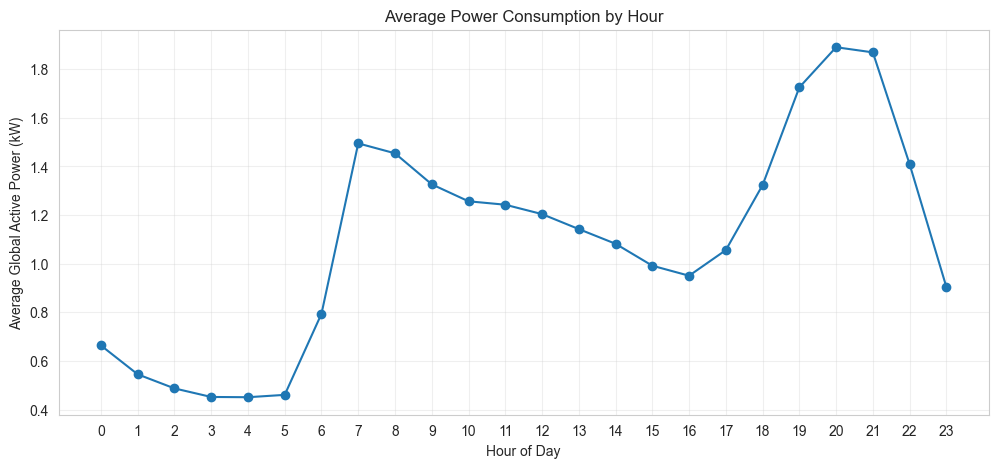

In [8]:
# Daily consumption pattern
hourly_avg = df.groupby('hour')['Global_active_power'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kW)')
plt.title('Average Power Consumption by Hour')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/figures/daily_pattern.png', dpi=100)
plt.show()

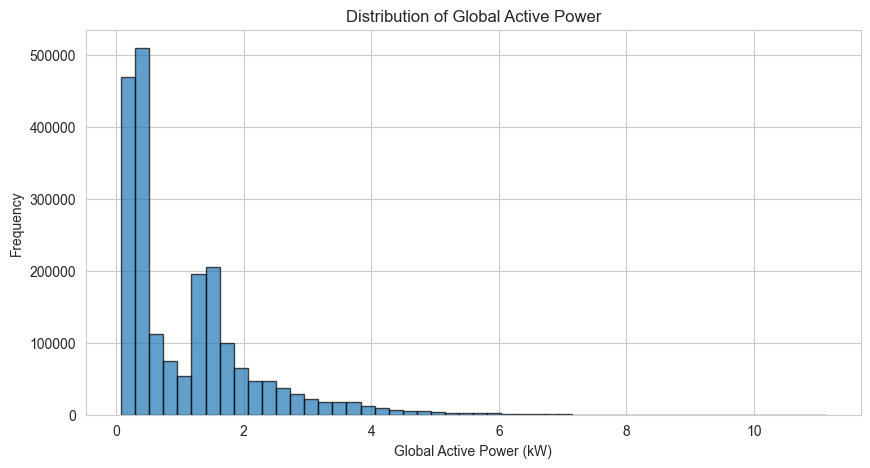

In [9]:
# Distribution of Global Active Power
plt.figure(figsize=(10, 5))
plt.hist(df['Global_active_power'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Global Active Power (kW)')
plt.ylabel('Frequency')
plt.title('Distribution of Global Active Power')
plt.savefig('../outputs/figures/power_distribution.png', dpi=100)
plt.show()

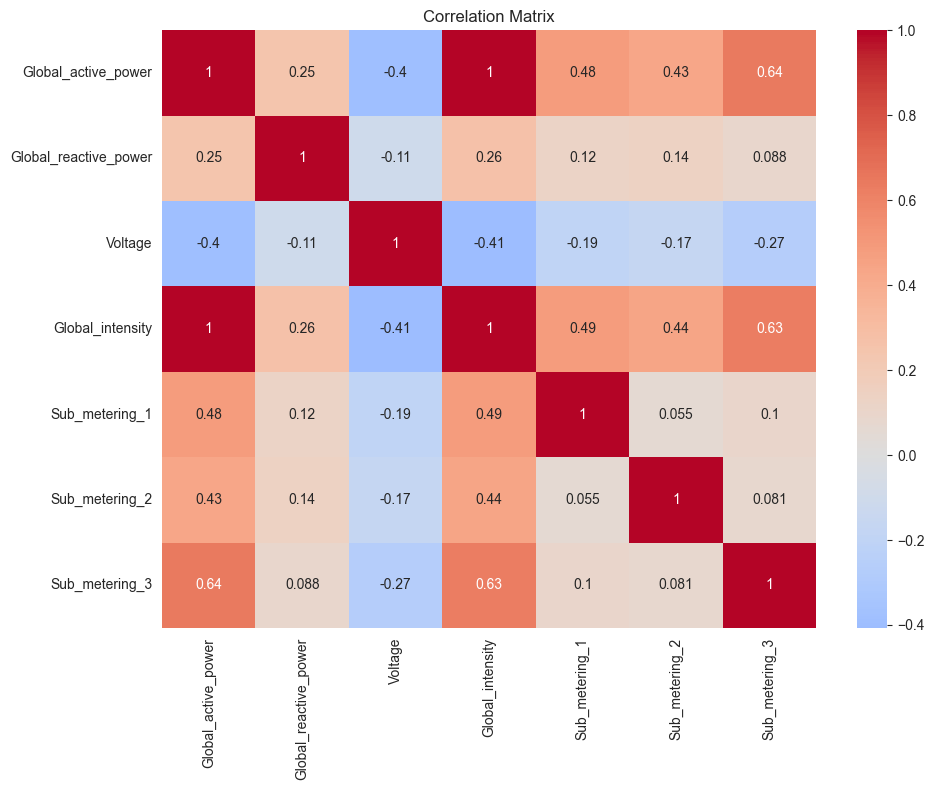

In [10]:
# Correlation heatmap
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

plt.figure(figsize=(10, 8))
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=100)
plt.show()

## 4. Save Processed Data

In [11]:
# Save for use in other notebooks
save_processed_data(df, '../data/processed/cleaned_data.csv')

Saved processed data to ../data/processed/cleaned_data.csv
